## Objective

This project analyzes the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using historical trading data from Hyperliquid.

The goal is to uncover patterns that can help understand how market sentiment influences trading behavior and profitability.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Better looking plots
plt.style.use("ggplot")

# Loading the Datasets

In [4]:
historical_data = pd.read_csv("/content/historical_data.csv")

fear_greed = pd.read_csv("/content/fear_greed_index.csv")

In [5]:
historical_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


# Data Understanding


In [7]:
print("Historical Data Shape")
print(historical_data.shape)

print()

print("Fear Greed Shape")
print(fear_greed.shape)

Historical Data Shape
(211224, 16)

Fear Greed Shape
(2644, 4)


In [8]:
historical_data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [9]:
fear_greed.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [10]:
historical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [11]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


# Missing Values


In [12]:
historical_data.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [13]:
fear_greed.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [14]:
historical_data.duplicated().sum()

np.int64(0)

In [15]:
fear_greed.duplicated().sum()

np.int64(0)

# Statistical Summary


In [16]:
historical_data.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


# Data Cleaning and Preparation


In [17]:
print("Historical Data Duplicates :", historical_data.duplicated().sum())
print("Fear & Greed Duplicates :", fear_greed.duplicated().sum())

Historical Data Duplicates : 0
Fear & Greed Duplicates : 0


In [18]:
historical_data["Timestamp IST"] = pd.to_datetime(
    historical_data["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

fear_greed["date"] = pd.to_datetime(fear_greed["date"])

In [19]:
historical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [20]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [21]:
historical_data["Date"] = historical_data["Timestamp IST"].dt.date

fear_greed["Date"] = fear_greed["date"].dt.date

In [22]:
historical_data[["Timestamp IST", "Date"]].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [23]:
fear_greed[["date", "Date"]].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [24]:
print("Historical Data")
print(historical_data["Date"].min())
print(historical_data["Date"].max())

Historical Data
2023-05-01
2025-05-01


In [25]:
print("Fear & Greed")
print(fear_greed["Date"].min())
print(fear_greed["Date"].max())

Fear & Greed
2018-02-01
2025-05-02


# Merging Historical Data with Fear & Greed Dataset


In [26]:
merged_data = pd.merge(
    historical_data,
    fear_greed[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

In [27]:
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [28]:
print("Merged Dataset Shape")
print(merged_data.shape)

Merged Dataset Shape
(211224, 19)


In [29]:
merged_data.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


# Exploratory Data Analysis


In [30]:
print("Total Trades :", len(merged_data))

Total Trades : 211224


In [31]:
merged_data["Account"].nunique()

32

In [32]:
merged_data["Coin"].value_counts()

,count
Coin,
HYPE,68005
@107,29992
BTC,26064
ETH,11158
SOL,10691
...,...
@18,1
@30,1
@25,1


In [33]:
merged_data["Side"].value_counts()

,count
Side,
SELL,108528
BUY,102696


In [34]:
merged_data["Closed PnL"].mean()

np.float64(48.74900079269401)

In [35]:
merged_data["Closed PnL"].max()

135329.0901

In [36]:
merged_data["Closed PnL"].min()

-117990.1041

In [37]:
merged_data["Fee"].mean()

np.float64(1.163966786755912)

In [38]:
merged_data["Size USD"].mean()

np.float64(5639.4512103738225)

# Relationship Between Market Sentiment and Trader Performance


In [40]:
merged_data.groupby("classification")["Closed PnL"].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


In [41]:
merged_data.groupby("classification")["Closed PnL"].sum()

,Closed PnL
classification,
Extreme Fear,7.391102e+05
Extreme Greed,2.715171e+06
Fear,3.357155e+06
Greed,2.150129e+06
Neutral,1.292921e+06


In [42]:
merged_data.groupby("classification")["Closed PnL"].median()

,Closed PnL
classification,
Extreme Fear,0.0
Extreme Greed,0.0
Fear,0.0
Greed,0.0
Neutral,0.0


In [43]:
merged_data.groupby("classification").size()

,0
classification,
Extreme Fear,21400
Extreme Greed,39992
Fear,61837
Greed,50303
Neutral,37686


In [44]:
merged_data.groupby("classification")["Size USD"].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


In [45]:
merged_data.groupby("classification")["Execution Price"].mean()

,Execution Price
classification,
Extreme Fear,7054.795108
Extreme Greed,6082.195865
Fear,14152.620222
Greed,13411.276344
Neutral,12393.692779


In [46]:
merged_data["Trade Result"] = merged_data["Closed PnL"].apply(
    lambda x: "Profit" if x > 0 else "Loss"
)

In [47]:
merged_data.groupby("classification")["Trade Result"].value_counts()

classification  Trade Result
Extreme Fear    Loss            13469
                Profit           7931
Extreme Greed   Loss            21398
                Profit          18594
Fear            Loss            35818
                Profit          26019
Greed           Loss            30945
                Profit          19358
Neutral         Loss            22725
                Profit          14961
Name: count, dtype: int64

# Data Visualization


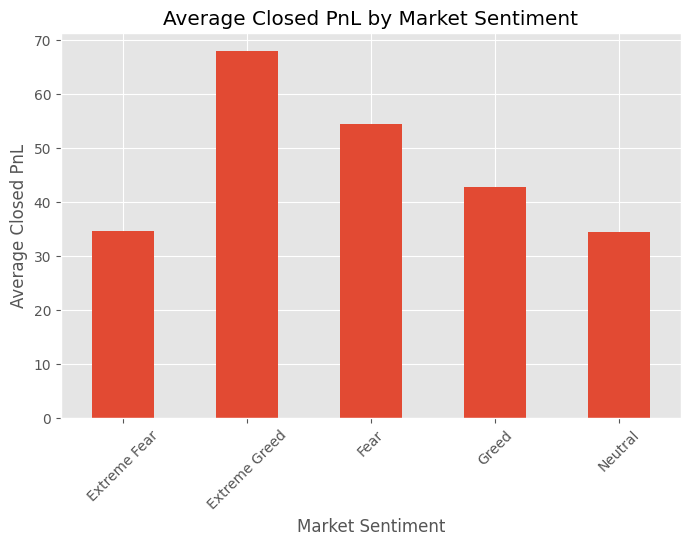

In [50]:
plt.figure(figsize=(8,5))

avg_profit = merged_data.groupby("classification")["Closed PnL"].mean()

avg_profit.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)

plt.show()

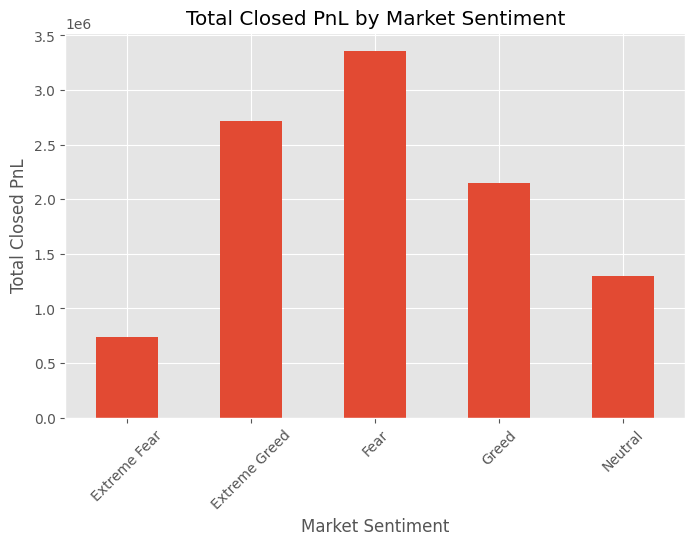

In [51]:
plt.figure(figsize=(8,5))

total_profit = merged_data.groupby("classification")["Closed PnL"].sum()

total_profit.plot(kind="bar")

plt.title("Total Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)

plt.show()

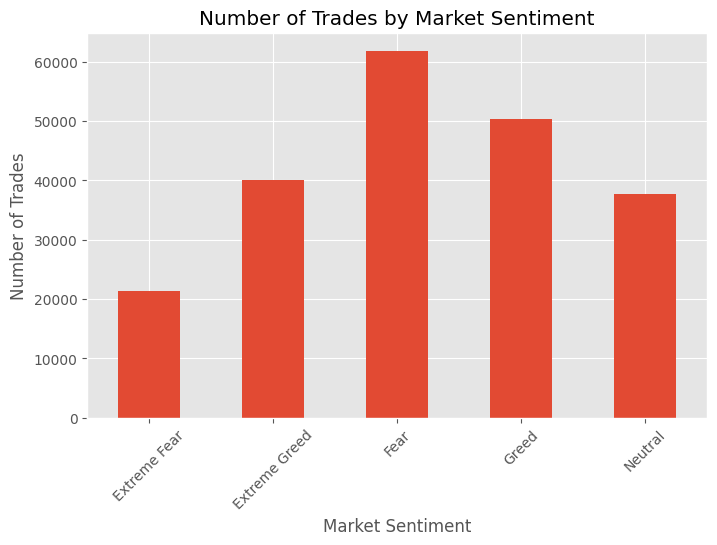

In [52]:
plt.figure(figsize=(8,5))

trade_count = merged_data.groupby("classification").size()

trade_count.plot(kind="bar")

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

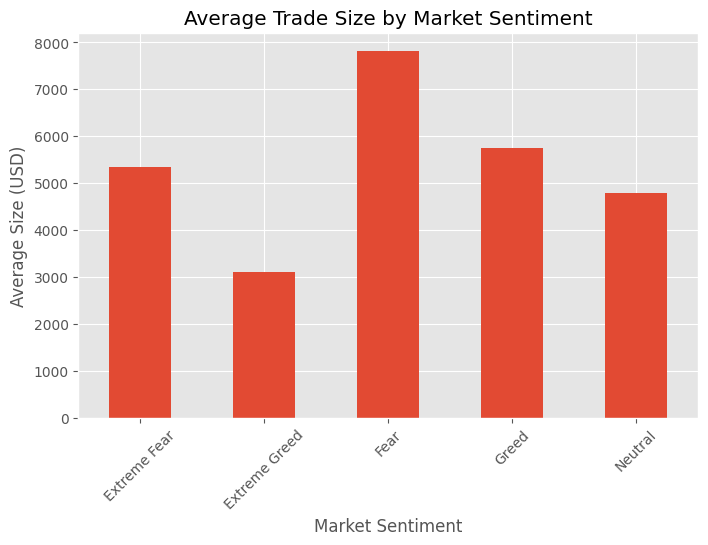

In [53]:
plt.figure(figsize=(8,5))

trade_size = merged_data.groupby("classification")["Size USD"].mean()

trade_size.plot(kind="bar")

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Size (USD)")
plt.xticks(rotation=45)

plt.show()

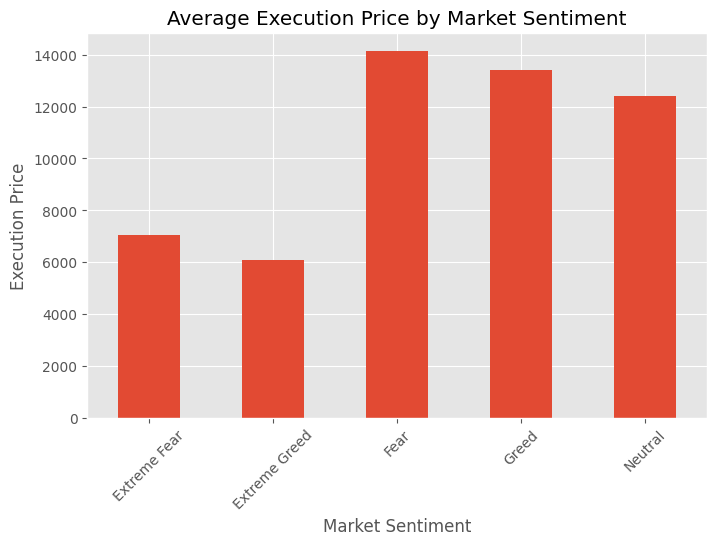

In [54]:
plt.figure(figsize=(8,5))

execution_price = merged_data.groupby("classification")["Execution Price"].mean()

execution_price.plot(kind="bar")

plt.title("Average Execution Price by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Execution Price")
plt.xticks(rotation=45)

plt.show()

<Figure size 1000x600 with 0 Axes>

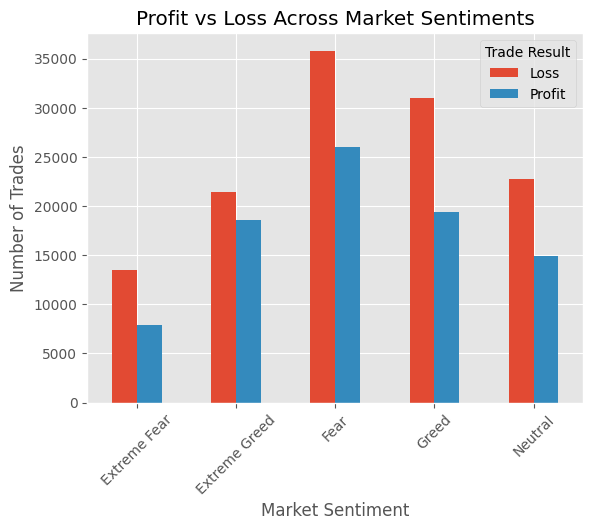

In [55]:
plt.figure(figsize=(10,6))

profit_loss = merged_data.groupby(
    ["classification", "Trade Result"]
).size().unstack()

profit_loss.plot(kind="bar")

plt.title("Profit vs Loss Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

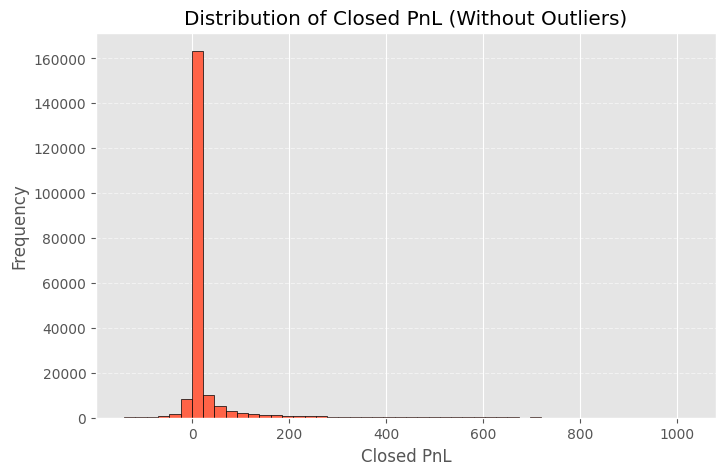

In [59]:
# Remove extreme outliers from Closed PnL using 1st and 99th percentiles

pnl = merged_data["Closed PnL"]

# Calculate lower and upper percentile limits
lower = pnl.quantile(0.01)   # 1st percentile
upper = pnl.quantile(0.99)   # 99th percentile

# Filter the data
pnl_filtered = pnl[(pnl >= lower) & (pnl <= upper)]

# Plot histogram
plt.figure(figsize=(8,5))

plt.hist(
    pnl_filtered,
    bins=50,
    color="tomato",
    edgecolor="black"
)

plt.title("Distribution of Closed PnL (Without Outliers)")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

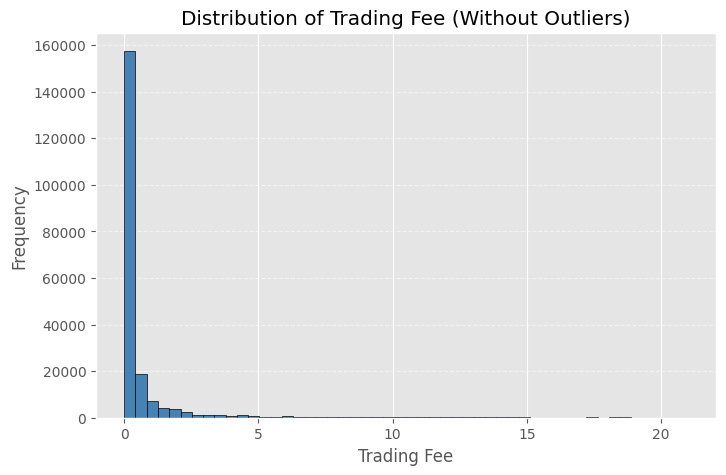

In [60]:
# Remove extreme outliers from Fee using 1st and 99th percentiles

fee = merged_data["Fee"]

# Calculate lower and upper percentile limits
lower = fee.quantile(0.01)   # 1st percentile
upper = fee.quantile(0.99)   # 99th percentile

# Filter the data
fee_filtered = fee[(fee >= lower) & (fee <= upper)]

# Plot histogram
plt.figure(figsize=(8,5))

plt.hist(
    fee_filtered,
    bins=50,
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Trading Fee (Without Outliers)")
plt.xlabel("Trading Fee")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

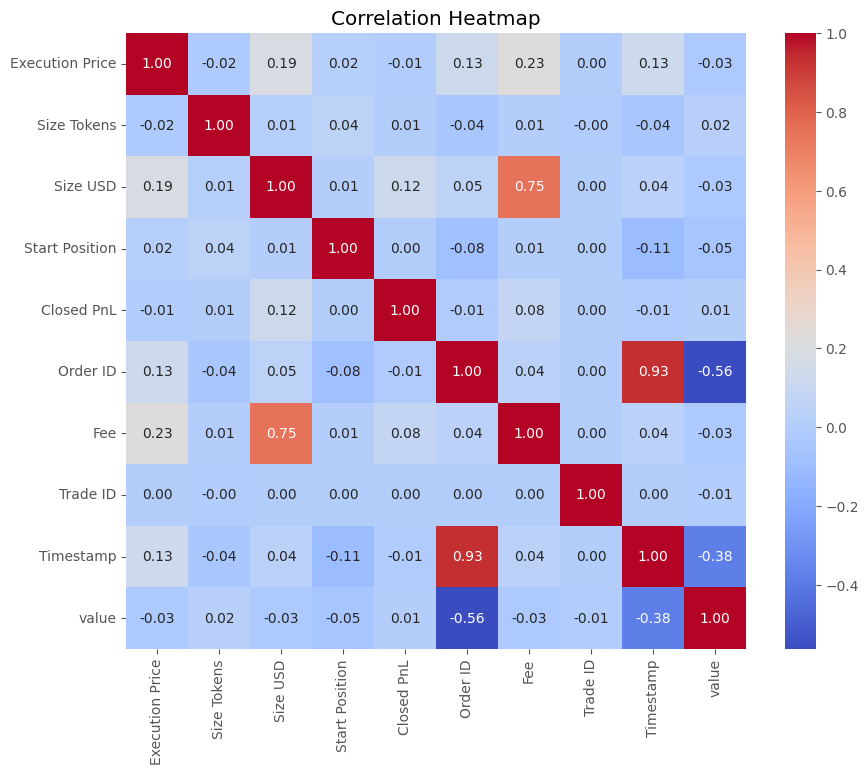

In [58]:
plt.figure(figsize=(10,8))

numeric_data = merged_data.select_dtypes(include=["number"])

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Conclusion






This project analyzed the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data. After preprocessing and merging the datasets based on the trading date, exploratory data analysis (EDA) was performed to identify patterns between market sentiment and trading behavior.

The analysis revealed the following key findings:

Fear periods recorded the highest number of trades, indicating that traders were more active during uncertain market conditions.
Extreme Greed showed the highest average Closed PnL, suggesting that traders achieved better average profits during strong bullish market sentiment.
The Fear category generated the highest total Closed PnL because it contained the largest number of trades.
The average trade size (USD) and execution price varied across different market sentiment categories, indicating that trader behavior changes with market conditions.
The Profit vs Loss analysis showed that losses were more frequent than profits across all market sentiment categories, although profitable trades were still significant.
The correlation heatmap indicated that most numerical features had weak correlations with Closed PnL, suggesting that trader profitability depends on multiple factors rather than a single variable.
Histograms of Closed PnL and Trading Fee showed highly skewed distributions, with most values concentrated near zero and a small number of large outliers. Removing these outliers provided a clearer understanding of the underlying data distribution.

Overall, the analysis suggests that market sentiment influences trading activity and performance, but it is not the only factor affecting profitability. Additional variables such as trading strategy, market volatility, leverage, and position management are likely to play an important role. Further analysis using predictive machine learning models could provide deeper insights into the relationship between market sentiment and trading outcomes.
